Processing 1981-1990...
Processing 1991-2000...
Processing 2001-2010...
Processing 2011-2020...
Processing 2020-2024...


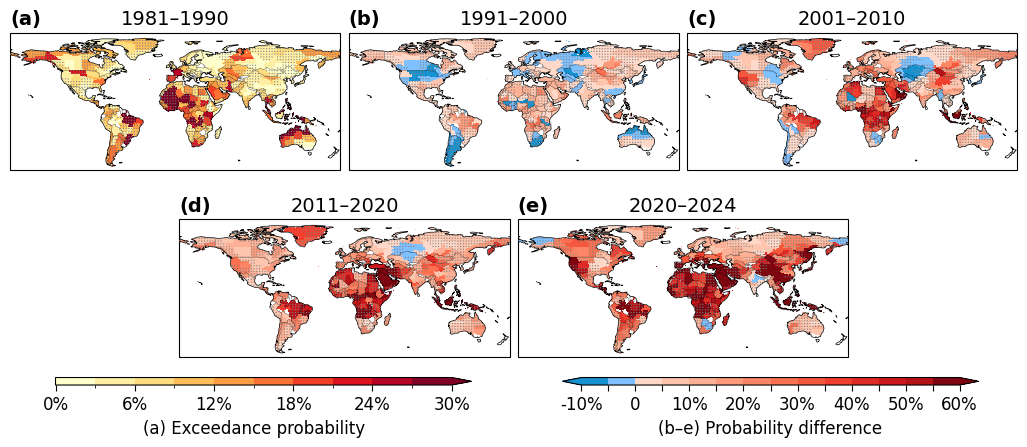

In [1]:
# update GEV，fix record
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
from matplotlib.colors import to_hex

# ====================================================
# 1. Load data
# ====================================================
ecmwf_ds = xr.open_dataset("IFS_t2m_hottest_month.nc")
rl_ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
mask_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc")
region_ids = mask_ds["region_id"].values

lat = mask_ds["latitude"].values
lon = mask_ds["longitude"].values

# Fidelity mask
fidelity_ds = xr.open_dataset("grid_comparison_fidelity_trend_corrected.nc")
fidelity = fidelity_ds["fidelity_score"]
fidelity_mask = fidelity == 3

# 低保真区域
low_fidelity_mask = (~fidelity_mask.values) & (~np.isnan(region_ids))

# 经纬度网格
lon2d, lat2d = np.meshgrid(lon, lat)

# ====================================================
# ↓↓↓ 新增：控制打点密度 ↓↓↓
# ====================================================
lat_stride = 3   # 每隔2个纬度
lon_stride = 3   # 每隔2个经度

stride_mask = np.zeros_like(low_fidelity_mask, dtype=bool)
stride_mask[::lat_stride, ::lon_stride] = True
# ====================================================

t2m_ifs_all = ecmwf_ds["t2m_hottest_month"]
t2m_berkeley_all = rl_ds["t2m_hottest"]

n_regions = 237

# ====================================================
# 2. Time periods
# ====================================================
time_periods = [
    (1981, 1990),
    (1991, 2000),
    (2001, 2010),
    (2011, 2020),
    (2020, 2024)
]
n_periods = len(time_periods)

# ====================================================
# 3. Fixed observed record
# ====================================================
def get_max_before_year(ds, start, end):
    sub = ds.sel(year=(ds.year >= start) & (ds.year <= end))
    return sub["t2m_hottest"].max(dim="year")

max_t2m = get_max_before_year(rl_ds, 1940, 1980)

# ====================================================
# 4. Containers
# ====================================================
prob_map = np.full((n_regions, n_periods), np.nan)
shape_base = np.full(n_regions, np.nan)
scale_base = np.full(n_regions, np.nan)

# ====================================================
# 5. Loop over periods
# ====================================================
for i, (start, end) in enumerate(time_periods):
    print(f"Processing {start}-{end}...")

    t2m_ifs_period = t2m_ifs_all.sel(year=(ecmwf_ds.year >= start) & (ecmwf_ds.year <= end))
    t2m_berkeley_period = t2m_berkeley_all.sel(year=(rl_ds.year >= start) & (rl_ds.year <= end))

    ifs_mean = t2m_ifs_period.mean(dim="year")
    berkeley_mean = t2m_berkeley_period.mean(dim="year")
    t2m_corrected = t2m_ifs_period - ifs_mean + berkeley_mean

    values = t2m_corrected.values.transpose(0, 2, 1).reshape(-1, n_regions)

    for r in range(n_regions):
        series = values[:, r]
        series = series[~np.isnan(series)]

        if len(series) < 30:
            continue

        try:
            # === 修改点：每个时期都独立拟合完整 GEV ===
            c, loc, scale = gev.fit(series)

            x = max_t2m.sel(region_id=r).item()
            F = gev.cdf(x, c, loc=loc, scale=scale)
            prob_map[r, i] = 1 - F

        except Exception:
            continue
            
# ====================================================
# 6. Plotting
# ====================================================
bounds = np.arange(0, 0.301, 0.03)
cmap = plt.get_cmap("YlOrRd", len(bounds) - 1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)


def plot_prob_map(region_data, title, ax,
                  dot_size=0.8,
                  dot_color='grey',
                  dot_alpha=1):

    map_data = np.full_like(region_ids, np.nan, dtype=np.float64)
    for r in range(n_regions):
        map_data[region_ids == r] = region_data[r]

    masked_data = np.ma.masked_invalid(map_data)

    im = ax.pcolormesh(
        lon, lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm
    )

    # === 稀疏 scatter ===
    valid_low_fidelity = (
        low_fidelity_mask &
        (~np.isnan(map_data)) &
        stride_mask
    )

    if np.any(valid_low_fidelity):
        ax.scatter(
            lon2d[valid_low_fidelity],
            lat2d[valid_low_fidelity],
            s=dot_size,
            color=dot_color,
            alpha=dot_alpha,
            marker='o',
            edgecolors='none',
            transform=ccrs.PlateCarree(),
            zorder=5
        )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)
    ax.set_title(title, fontsize=14)

    return im


# ====================================================
# 主图函数
# ====================================================
def plot_gev_probability_grid(prob_map, fig_title):
    fig = plt.figure(figsize=(13, 5))
    gs = GridSpec(2, 6, figure=fig, height_ratios=[1, 0.9])

    ax_a = fig.add_subplot(gs[0, 0:2], projection=ccrs.PlateCarree())
    ax_b = fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree())
    ax_c = fig.add_subplot(gs[0, 4:6], projection=ccrs.PlateCarree())

    ax_d = fig.add_subplot(gs[1, 1:3], projection=ccrs.PlateCarree())
    ax_e = fig.add_subplot(gs[1, 3:5], projection=ccrs.PlateCarree())

    axs = [ax_a, ax_b, ax_c, ax_d, ax_e]
    labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

    diff_bounds = np.arange(-0.10, 0.601, 0.05)

    blue_colors = ['#1692d0', '#7fc0ff']
    red_colors_rgba = [cm.Reds(x) for x in np.linspace(0.15, 0.95,
                                                         len(diff_bounds) - len(blue_colors))]
    red_colors = [to_hex(c) for c in red_colors_rgba]
    custom_colors = blue_colors + red_colors

    cmap_diff = ListedColormap(custom_colors)
    norm_diff = BoundaryNorm(boundaries=diff_bounds,
                              ncolors=len(custom_colors))

    for i, ax in enumerate(axs):
        title = f"{time_periods[i][0]}–{time_periods[i][1]}"

        if i == 0:
            data = prob_map[:, i]
            plot_prob_map(data, title, ax)

        else:
            diff = prob_map[:, i] - prob_map[:, 0]

            map_data = np.full_like(region_ids, np.nan, dtype=np.float64)
            for r in range(n_regions):
                map_data[region_ids == r] = diff[r]

            masked_data = np.ma.masked_invalid(map_data)

            ax.pcolormesh(
                lon, lat, masked_data,
                transform=ccrs.PlateCarree(),
                cmap=cmap_diff,
                norm=norm_diff
            )

            # === 稀疏 scatter ===
            valid_low_fidelity = (
                low_fidelity_mask &
                (~np.isnan(map_data)) &
                stride_mask
                )
            if np.any(valid_low_fidelity):
                ax.scatter(
                    lon2d[valid_low_fidelity],
                    lat2d[valid_low_fidelity],
                    s=0.8,
                    color='grey',
                    marker='o',       # 实心圆
                    edgecolors='none',
                    transform=ccrs.PlateCarree(),
                    zorder=5
                )

            ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.2)
            ax.set_title(title, fontsize=14)

        ax.text(0.0, 1.03, labels[i],
                transform=ax.transAxes,
                fontsize=14,
                fontweight='bold',
                ha='left',
                va='bottom')

    fig.subplots_adjust(wspace=0.05, hspace=0.02, top=0.92, bottom=0.18)

    formatter_raw = FuncFormatter(lambda x, _: f"{x * 100:.0f}%")
    formatter_diff = FuncFormatter(lambda x, _: f"{x * 100:.0f}%" if x != 0 else "0")

    ticks_raw = np.arange(0, 0.31, 0.06)
    ticks_diff = diff_bounds

    cbar_ax_raw = fig.add_axes([0.16, 0.16, 0.32, 0.015])
    cmap_clean = plt.get_cmap("YlOrRd", len(bounds) - 1)
    norm_clean = BoundaryNorm(boundaries=bounds, ncolors=cmap_clean.N)

    cbar_raw = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm_clean, cmap=cmap_clean),
        cax=cbar_ax_raw,
        orientation='horizontal',
        ticks=ticks_raw,
        extend='max'
    )
    cbar_raw.set_label("(a) Exceedance probability", fontsize=12)
    cbar_raw.ax.set_xticklabels([formatter_raw(t) for t in ticks_raw])
    cbar_raw.ax.tick_params(labelsize=12,length=4)
    cbar_ax_diff = fig.add_axes([0.55, 0.16, 0.32, 0.015])
    cbar_diff = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm_diff, cmap=cmap_diff),
        cax=cbar_ax_diff,
        orientation='horizontal',
        ticks=ticks_diff,
        extend='both'
    )
    cbar_diff.set_label("(b–e) Probability difference", fontsize=12)
    cbar_diff.ax.set_xticklabels([
        formatter_diff(t) if i % 2 == 0 else ""
        for i, t in enumerate(ticks_diff)
    ])
    cbar_diff.ax.tick_params(labelsize=12,length=4)
    plt.savefig("Fig4_Fixed_record_update_GEV_dots.pdf",
                dpi=800, bbox_inches='tight')
    plt.show()


# ====================================================
# 执行绘图
# ====================================================
plot_gev_probability_grid(
    prob_map,
    "Probability of record-breaking events (fixed shape & scale, evolving loc)"
)


Processing 1981-1990...
Processing 1991-2000...
Processing 2001-2010...
Processing 2011-2020...
Processing 2020-2024...


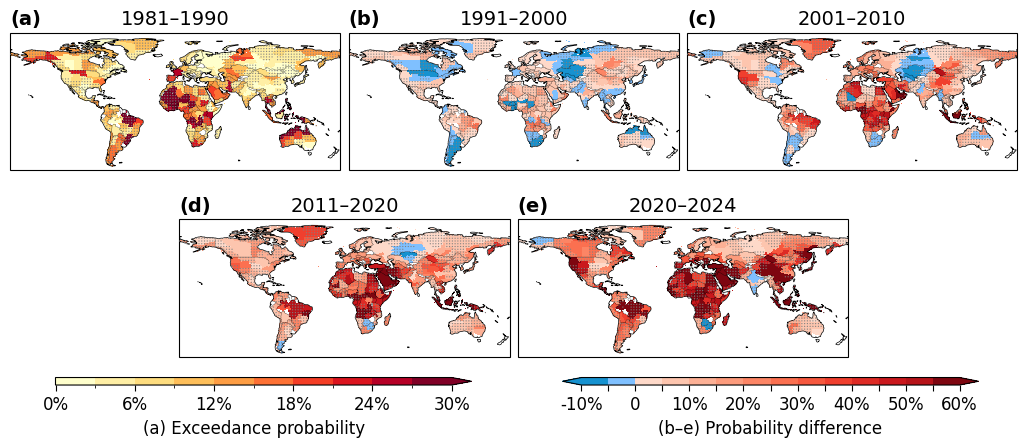

In [2]:
# only update location，keep scale,shape fixed
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
from matplotlib.colors import to_hex

# ====================================================
# 1. Load data
# ====================================================
ecmwf_ds = xr.open_dataset("IFS_t2m_hottest_month.nc")
rl_ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
mask_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc")
region_ids = mask_ds["region_id"].values

lat = mask_ds["latitude"].values
lon = mask_ds["longitude"].values

# Fidelity mask
fidelity_ds = xr.open_dataset("grid_comparison_fidelity_trend_corrected.nc")
fidelity = fidelity_ds["fidelity_score"]
fidelity_mask = fidelity == 3

# 低保真区域
low_fidelity_mask = (~fidelity_mask.values) & (~np.isnan(region_ids))

# 经纬度网格
lon2d, lat2d = np.meshgrid(lon, lat)

# ====================================================
# ↓↓↓ 新增：控制打点密度 ↓↓↓
# ====================================================
lat_stride = 3   # 每隔2个纬度
lon_stride = 3   # 每隔2个经度

stride_mask = np.zeros_like(low_fidelity_mask, dtype=bool)
stride_mask[::lat_stride, ::lon_stride] = True
# ====================================================

t2m_ifs_all = ecmwf_ds["t2m_hottest_month"]
t2m_berkeley_all = rl_ds["t2m_hottest"]

n_regions = 237

# ====================================================
# 2. Time periods
# ====================================================
time_periods = [
    (1981, 1990),
    (1991, 2000),
    (2001, 2010),
    (2011, 2020),
    (2020, 2024)
]
n_periods = len(time_periods)

# ====================================================
# 3. Fixed observed record
# ====================================================
def get_max_before_year(ds, start, end):
    sub = ds.sel(year=(ds.year >= start) & (ds.year <= end))
    return sub["t2m_hottest"].max(dim="year")

max_t2m = get_max_before_year(rl_ds, 1940, 1980)

# ====================================================
# 4. Containers
# ====================================================
prob_map = np.full((n_regions, n_periods), np.nan)
shape_base = np.full(n_regions, np.nan)
scale_base = np.full(n_regions, np.nan)

# ====================================================
# 5. Loop over periods
# ====================================================
for i, (start, end) in enumerate(time_periods):
    print(f"Processing {start}-{end}...")

    t2m_ifs_period = t2m_ifs_all.sel(year=(ecmwf_ds.year >= start) & (ecmwf_ds.year <= end))
    t2m_berkeley_period = t2m_berkeley_all.sel(year=(rl_ds.year >= start) & (rl_ds.year <= end))

    ifs_mean = t2m_ifs_period.mean(dim="year")
    berkeley_mean = t2m_berkeley_period.mean(dim="year")
    t2m_corrected = t2m_ifs_period - ifs_mean + berkeley_mean

    values = t2m_corrected.values.transpose(0, 2, 1).reshape(-1, n_regions)

    for r in range(n_regions):
        series = values[:, r]
        series = series[~np.isnan(series)]

        if len(series) < 30:
            continue

        try:
            if i == 0:
                c, loc, scale = gev.fit(series)
                shape_base[r] = c
                scale_base[r] = scale
            else:
                if np.isnan(shape_base[r]) or np.isnan(scale_base[r]):
                    continue

                c_fixed = shape_base[r]
                scale_fixed = scale_base[r]
                c, loc, scale = gev.fit(series)
                c = c_fixed
                scale = scale_fixed

            x = max_t2m.sel(region_id=r).item()
            F = gev.cdf(x, c, loc=loc, scale=scale)
            prob_map[r, i] = 1 - F

        except Exception:
            continue

# ====================================================
# 6. Plotting
# ====================================================
bounds = np.arange(0, 0.301, 0.03)
cmap = plt.get_cmap("YlOrRd", len(bounds) - 1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)


def plot_prob_map(region_data, title, ax,
                  dot_size=0.8,
                  dot_color='grey',
                  dot_alpha=1):

    map_data = np.full_like(region_ids, np.nan, dtype=np.float64)
    for r in range(n_regions):
        map_data[region_ids == r] = region_data[r]

    masked_data = np.ma.masked_invalid(map_data)

    im = ax.pcolormesh(
        lon, lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm
    )

    # === 稀疏 scatter ===
    valid_low_fidelity = (
        low_fidelity_mask &
        (~np.isnan(map_data)) &
        stride_mask
    )

    if np.any(valid_low_fidelity):
        ax.scatter(
            lon2d[valid_low_fidelity],
            lat2d[valid_low_fidelity],
            s=dot_size,
            color=dot_color,
            alpha=dot_alpha,
            marker='o',
            edgecolors='none',
            transform=ccrs.PlateCarree(),
            zorder=5
        )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)
    ax.set_title(title, fontsize=14)

    return im


# ====================================================
# 主图函数
# ====================================================
def plot_gev_probability_grid(prob_map, fig_title):
    fig = plt.figure(figsize=(13, 5))
    gs = GridSpec(2, 6, figure=fig, height_ratios=[1, 0.9])

    ax_a = fig.add_subplot(gs[0, 0:2], projection=ccrs.PlateCarree())
    ax_b = fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree())
    ax_c = fig.add_subplot(gs[0, 4:6], projection=ccrs.PlateCarree())

    ax_d = fig.add_subplot(gs[1, 1:3], projection=ccrs.PlateCarree())
    ax_e = fig.add_subplot(gs[1, 3:5], projection=ccrs.PlateCarree())

    axs = [ax_a, ax_b, ax_c, ax_d, ax_e]
    labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

    diff_bounds = np.arange(-0.10, 0.601, 0.05)

    blue_colors = ['#1692d0', '#7fc0ff']
    red_colors_rgba = [cm.Reds(x) for x in np.linspace(0.15, 0.95,
                                                         len(diff_bounds) - len(blue_colors))]
    red_colors = [to_hex(c) for c in red_colors_rgba]
    custom_colors = blue_colors + red_colors

    cmap_diff = ListedColormap(custom_colors)
    norm_diff = BoundaryNorm(boundaries=diff_bounds,
                              ncolors=len(custom_colors))

    for i, ax in enumerate(axs):
        title = f"{time_periods[i][0]}–{time_periods[i][1]}"

        if i == 0:
            data = prob_map[:, i]
            plot_prob_map(data, title, ax)

        else:
            diff = prob_map[:, i] - prob_map[:, 0]

            map_data = np.full_like(region_ids, np.nan, dtype=np.float64)
            for r in range(n_regions):
                map_data[region_ids == r] = diff[r]

            masked_data = np.ma.masked_invalid(map_data)

            ax.pcolormesh(
                lon, lat, masked_data,
                transform=ccrs.PlateCarree(),
                cmap=cmap_diff,
                norm=norm_diff
            )

            # === 稀疏 scatter ===
            valid_low_fidelity = (
                low_fidelity_mask &
                (~np.isnan(map_data)) &
                stride_mask
                )
            if np.any(valid_low_fidelity):
                ax.scatter(
                    lon2d[valid_low_fidelity],
                    lat2d[valid_low_fidelity],
                    s=0.8,
                    color='grey',
                    marker='o',       # 实心圆
                    edgecolors='none',
                    transform=ccrs.PlateCarree(),
                    zorder=5
                )

            ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.2)
            ax.set_title(title, fontsize=14)

        ax.text(0.00, 1.03, labels[i],
                transform=ax.transAxes,
                fontsize=14,
                fontweight='bold',
                ha='left',
                va='bottom')

    fig.subplots_adjust(wspace=0.05, hspace=0.02, top=0.92, bottom=0.18)

    formatter_raw = FuncFormatter(lambda x, _: f"{x * 100:.0f}%")
    formatter_diff = FuncFormatter(lambda x, _: f"{x * 100:.0f}%" if x != 0 else "0")

    ticks_raw = np.arange(0, 0.31, 0.06)
    ticks_diff = diff_bounds

    cbar_ax_raw = fig.add_axes([0.16, 0.16, 0.32, 0.015])
    
    cmap_clean = plt.get_cmap("YlOrRd", len(bounds) - 1)
    norm_clean = BoundaryNorm(boundaries=bounds, ncolors=cmap_clean.N)

    cbar_raw = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm_clean, cmap=cmap_clean),
        cax=cbar_ax_raw,
        orientation='horizontal',
        ticks=ticks_raw,
        extend='max'
    )
    cbar_raw.set_label("(a) Exceedance probability",fontsize=12)
    cbar_raw.ax.set_xticklabels([formatter_raw(t) for t in ticks_raw])
    cbar_raw.ax.tick_params(labelsize=12,length=4)

    cbar_ax_diff = fig.add_axes([0.55, 0.16, 0.32, 0.015])
    
    cbar_diff = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm_diff, cmap=cmap_diff),
        cax=cbar_ax_diff,
        orientation='horizontal',
        ticks=ticks_diff,
        extend='both'
    )
    cbar_diff.set_label("(b–e) Probability difference",fontsize=12)
    cbar_diff.ax.set_xticklabels([
        formatter_diff(t) if i % 2 == 0 else ""
        for i, t in enumerate(ticks_diff)
    ])
    cbar_diff.ax.tick_params(labelsize=12,length=4)
    plt.savefig("FigS3_Fixed_record_update_loc_dots.pdf",
                dpi=800, bbox_inches='tight')
    plt.show()


# ====================================================
# 执行绘图
# ====================================================
plot_gev_probability_grid(
    prob_map,
    "Probability of record-breaking events (fixed shape & scale, evolving loc)"
)
